
<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Certification Project Statement - PHARMA </h2>
</div>

<div class="alert alert-info" style="background-color:#001b92; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

## Maple Leaves Ltd is a start-up company which makes herbs from different types of plants and its leaves. 
- Currently the system they use to classify the trees which they import in a batch is quite manual. 
- A labourer from his experience decides the leaf type and subtype of plant family. 
- They have asked us to automate this process and remove any manual intervention from this process.

## Objective: 
- To classify the plant leaves by various classifiers from different metrics of the leaves and to choose the best classifier for future reference.

## Implementation:
- 1) Import the train and test csv. 
- 2) Import the required classification libraries along with pandas, numpy, seaborn etc
- 3) Then import the classifiers from them (Randomforest, SVM, NaiveBayes, DecisionTrees)
- 4) After this create a function to encode the labels of the strings given in the dataset
- 5) You can do the above step using label encoder. With this you are creating some labels from train set as test set. The test set we imported is for testing the best classifier accuracy once we choose it
- 6) Then extract the values from train set by stratifying them and dividing it into 80:20 ratio
- 7) Now your X train, X test, Y train, Y test are ready.
- 8) We currently don’t know which is the best classifier on the dataset. So,we apply all 4 of them.
- 9) Create the classifiers class and initialize all the respective classifiers
- 10) Then run the X train & X test datasets through classifiers calculating the log loss and accuracy of the result
- 11) Choose the classifier which has the best accuracy
- 12) Then try to predict the result on the import test.csv dataset


##  1. Import all Library

##### 1) Import the train and test csv.
##### 2) Import the required classification libraries along with pandas, numpy, seaborn etc
##### 3) Then import the classifiers from them (Randomforest, SVM, NaiveBayes, DecisionTrees)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree

from sklearn import metrics

> Read the data file

In [2]:

# data load, used thousands = ',' to convert , in data to normal integer
train_pharma = pd.read_csv(r'..\CTS_3_PHARMA\Dataset\train.csv')
test_pharma = pd.read_csv(r'..\CTS_3_PHARMA\Dataset\test.csv')

train_pharma.head()

,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,1,Acer_Opalus,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,...,0.007812,0.000000,0.002930,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391
1,2,Pterocarya_Stenoptera,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,...,0.000977,0.000000,0.000000,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461
2,3,Quercus_Hartwissiana,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,...,0.154300,0.000000,0.005859,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930
3,5,Tilia_Tomentosa,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,...,0.000000,0.000977,0.000000,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852
4,6,Quercus_Variabilis,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,...,0.096680,0.000000,0.021484,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250


In [3]:
test_pharma.head()

,id,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,margin9,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,4,0.019531,0.009766,0.078125,0.011719,0.003906,0.015625,0.005859,0.0,0.005859,...,0.006836,0.000000,0.015625,0.000977,0.015625,0.0,0.0,0.000000,0.003906,0.053711
1,7,0.007812,0.005859,0.064453,0.009766,0.003906,0.013672,0.007812,0.0,0.033203,...,0.000000,0.000000,0.006836,0.001953,0.013672,0.0,0.0,0.000977,0.037109,0.044922
2,9,0.000000,0.000000,0.001953,0.021484,0.041016,0.000000,0.023438,0.0,0.011719,...,0.128910,0.000000,0.000977,0.000000,0.000000,0.0,0.0,0.015625,0.000000,0.000000
3,12,0.000000,0.000000,0.009766,0.011719,0.017578,0.000000,0.003906,0.0,0.003906,...,0.012695,0.015625,0.002930,0.036133,0.013672,0.0,0.0,0.089844,0.000000,0.008789
4,13,0.001953,0.000000,0.015625,0.009766,0.039062,0.000000,0.009766,0.0,0.005859,...,0.000000,0.042969,0.016602,0.010742,0.041016,0.0,0.0,0.007812,0.009766,0.007812


> Here species is output column, which is there in Training dataset

## 2. Data wrangling

In [4]:
#find null in col
train_pharma.isnull().sum()
## No null/Missing value in data set

id           0
species      0
margin1      0
margin2      0
margin3      0
margin4      0
margin5      0
margin6      0
margin7      0
margin8      0
margin9      0
margin10     0
margin11     0
margin12     0
margin13     0
margin14     0
margin15     0
margin16     0
margin17     0
margin18     0
margin19     0
margin20     0
margin21     0
margin22     0
margin23     0
margin24     0
margin25     0
margin26     0
margin27     0
margin28     0
            ..
texture35    0
texture36    0
texture37    0
texture38    0
texture39    0
texture40    0
texture41    0
texture42    0
texture43    0
texture44    0
texture45    0
texture46    0
texture47    0
texture48    0
texture49    0
texture50    0
texture51    0
texture52    0
texture53    0
texture54    0
texture55    0
texture56    0
texture57    0
texture58    0
texture59    0
texture60    0
texture61    0
texture62    0
texture63    0
texture64    0
Length: 194, dtype: int64

In [5]:
# Remove Id colum
train_pharma.drop(['id'], axis = 1, inplace= True)
test_pharma.drop(['id'], axis = 1, inplace= True)

In [6]:
train_pharma.head()

,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,margin9,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,Acer_Opalus,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,0.001953,...,0.007812,0.000000,0.002930,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391
1,Pterocarya_Stenoptera,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,0.000000,...,0.000977,0.000000,0.000000,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461
2,Quercus_Hartwissiana,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,0.000000,...,0.154300,0.000000,0.005859,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930
3,Tilia_Tomentosa,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,0.013672,...,0.000000,0.000977,0.000000,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852
4,Quercus_Variabilis,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,0.000000,...,0.096680,0.000000,0.021484,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250


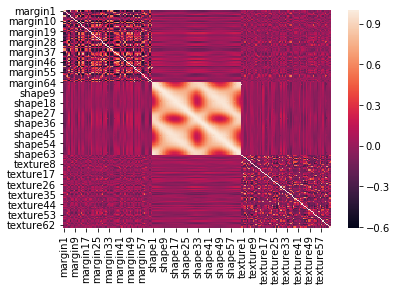

In [7]:
# Apply seaborn to see correlation
correlation = train_pharma.corr()
sn.heatmap(correlation)

### 2.1 Split the Data

###### 4) After this create a function to encode the labels of the strings given in the dataset
###### 5) You can do the above step using label encoder. With this you are creating some labels from train set as test set. The test set we imported is for testing the best classifier accuracy once we choose it


In [8]:
## Split the label data 
train_pharma_X = train_pharma.iloc[:,1:]
train_pharma_Y = train_pharma.iloc[:,0]
#train_pharma_Y.head()


#train_pharma_X = train_pharma.iloc[:,1:65]
train_pharma_X.head()


,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,margin9,margin10,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,0.001953,0.033203,...,0.007812,0.000000,0.002930,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391
1,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,0.000000,0.007812,...,0.000977,0.000000,0.000000,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461
2,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,0.000000,0.044922,...,0.154300,0.000000,0.005859,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930
3,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,0.013672,0.017578,...,0.000000,0.000977,0.000000,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852
4,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,0.000000,0.005859,...,0.096680,0.000000,0.021484,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250


In [9]:
train_pharma_Y[:10]

0              Acer_Opalus
1    Pterocarya_Stenoptera
2     Quercus_Hartwissiana
3          Tilia_Tomentosa
4       Quercus_Variabilis
5     Magnolia_Salicifolia
6      Quercus_Canariensis
7            Quercus_Rubra
8          Quercus_Brantii
9           Salix_Fragilis
Name: species, dtype: object

In [10]:
np.unique(train_pharma_Y)

array(['Acer_Capillipes', 'Acer_Circinatum', 'Acer_Mono', 'Acer_Opalus',
       'Acer_Palmatum', 'Acer_Pictum', 'Acer_Platanoids', 'Acer_Rubrum',
       'Acer_Rufinerve', 'Acer_Saccharinum', 'Alnus_Cordata',
       'Alnus_Maximowiczii', 'Alnus_Rubra', 'Alnus_Sieboldiana',
       'Alnus_Viridis', 'Arundinaria_Simonii', 'Betula_Austrosinensis',
       'Betula_Pendula', 'Callicarpa_Bodinieri', 'Castanea_Sativa',
       'Celtis_Koraiensis', 'Cercis_Siliquastrum', 'Cornus_Chinensis',
       'Cornus_Controversa', 'Cornus_Macrophylla', 'Cotinus_Coggygria',
       'Crataegus_Monogyna', 'Cytisus_Battandieri',
       'Eucalyptus_Glaucescens', 'Eucalyptus_Neglecta',
       'Eucalyptus_Urnigera', 'Fagus_Sylvatica', 'Ginkgo_Biloba',
       'Ilex_Aquifolium', 'Ilex_Cornuta', 'Liquidambar_Styraciflua',
       'Liriodendron_Tulipifera', 'Lithocarpus_Cleistocarpus',
       'Lithocarpus_Edulis', 'Magnolia_Heptapeta', 'Magnolia_Salicifolia',
       'Morus_Nigra', 'Olea_Europaea', 'Phildelphus', 'Populus_

### 2.2 Apply label encode on o/p

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_pharma_Y = le.fit_transform(train_pharma_Y)

print(train_pharma_Y[:5])
print(le.inverse_transform(train_pharma_Y))


[ 3 49 65 94 84]
['Acer_Opalus' 'Pterocarya_Stenoptera' 'Quercus_Hartwissiana'
 'Tilia_Tomentosa' 'Quercus_Variabilis' 'Magnolia_Salicifolia'
 'Quercus_Canariensis' 'Quercus_Rubra' 'Quercus_Brantii' 'Salix_Fragilis'
 'Zelkova_Serrata' 'Betula_Austrosinensis' 'Quercus_Pontica'
 'Quercus_Afares' 'Quercus_Coccifera' 'Fagus_Sylvatica' 'Phildelphus'
 'Acer_Palmatum' 'Quercus_Pubescens' 'Populus_Adenopoda' 'Quercus_Trojana'
 'Quercus_Variabilis' 'Alnus_Sieboldiana' 'Quercus_Ilex'
 'Arundinaria_Simonii' 'Acer_Platanoids' 'Quercus_Phillyraeoides'
 'Cornus_Chinensis' 'Quercus_Phillyraeoides' 'Fagus_Sylvatica'
 'Liriodendron_Tulipifera' 'Cytisus_Battandieri' 'Tilia_Tomentosa'
 'Rhododendron_x_Russellianum' 'Alnus_Rubra' 'Eucalyptus_Glaucescens'
 'Cercis_Siliquastrum' 'Cotinus_Coggygria' 'Celtis_Koraiensis'
 'Quercus_Crassifolia' 'Quercus_Variabilis' 'Quercus_Hartwissiana'
 'Quercus_Kewensis' 'Quercus_Coccifera' 'Cornus_Controversa'
 'Quercus_Pyrenaica' 'Callicarpa_Bodinieri' 'Quercus_Alnifolia'


### 2.3 Split Train data only as train and test with 80:20

##### 6) Then extract the values from train set by stratifying them and dividing it into 80:20 ratio
##### 7) Now your X train, X test, Y train, Y test are ready.

- TRAIN_TEST_SPLIT on Train data which has o/p


In [12]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_Y,test_Y = train_test_split(train_pharma_X,train_pharma_Y, test_size = .20, random_state=5)

### 2.4  APPLY PCA

- Many numerical col are there, so will check with PCA to reduce dimentionality with less col(PCA)

#### Apply PCA on test_X and train_X, which has many numeric col and test accuracy

In [13]:
# Implementing the PCA and resducing the number of columns
from sklearn.decomposition import PCA

for i in range(1,51):
    pca_model = PCA(n_components=i)
    pca_model.fit(train_X)

    # transform the data from multidimension to 2D
    data_2d = pca_model.transform(train_X)
    data_df_2d = pd.DataFrame(data_2d)
    a = pca_model.explained_variance_ratio_
    print("n component = %s total varience is %s " %( i, a.sum()))


n component = 1 total varience is 0.15418254480587146 
n component = 2 total varience is 0.2532445293362226 
n component = 3 total varience is 0.33993550843040926 
n component = 4 total varience is 0.4095104431835811 
n component = 5 total varience is 0.4611405936496511 
n component = 6 total varience is 0.505693448052516 
n component = 7 total varience is 0.547333995855617 
n component = 8 total varience is 0.5855946608748617 
n component = 9 total varience is 0.6176017252896289 
n component = 10 total varience is 0.6474229284565705 
n component = 11 total varience is 0.6742955446265368 
n component = 12 total varience is 0.6971050457420758 
n component = 13 total varience is 0.7169676637495768 
n component = 14 total varience is 0.7351640236660779 
n component = 15 total varience is 0.7521188374013339 
n component = 16 total varience is 0.7681430713153165 
n component = 17 total varience is 0.7829307740694607 
n component = 18 total varience is 0.7967870513324903 
n component = 19 to

* Will take n component = 50 total varience is 0.9545002751479272 

In [14]:
#Apply PCA with n_components=50
pca_model = PCA(n_components=50)
pca_model.fit(train_X)

# transform the data from multidimension to reduced Dimension
train_pca_X = pca_model.transform(train_X)
train_pca_X = pd.DataFrame(train_pca_X)
a = pca_model.explained_variance_ratio_

print(a.sum())
print(train_pca_X.head())

# transform the data from multidimension to reduced Dimension
test_pca_X = pca_model.transform(test_X)
test_pca_X = pd.DataFrame(test_pca_X)

print(test_pca_X.head())

0.9545479357947556
         0         1         2         3         4         5         6   \
0 -0.025863  0.341820  0.151887 -0.271195  0.303023  0.168246 -0.163909   
1 -0.028265 -0.087828  0.001176 -0.015744  0.041854 -0.028305  0.036097   
2 -0.038998 -0.075319  0.009133 -0.057413  0.006481  0.105767 -0.065417   
3  0.158149  0.049254 -0.044897 -0.001828  0.021712 -0.056179  0.047010   
4  0.142541  0.030776  0.020964 -0.000284 -0.021395  0.089963 -0.021271   

         7         8         9     ...           40        41        42  \
0  0.347372  0.121800  0.118209    ...     0.021575 -0.007497  0.029326   
1 -0.014652  0.012472  0.042247    ...     0.042291  0.003404 -0.004565   
2 -0.092722 -0.015276  0.032858    ...    -0.004728  0.017829  0.012534   
3 -0.007768  0.055031 -0.016703    ...     0.012266  0.009721  0.024651   
4 -0.077550 -0.005941  0.024967    ...     0.019161 -0.005669 -0.009272   

         43        44        45        46        47        48        49  
0 -0.

In [15]:
#1. Apply RF on PCA dataset


model = RandomForestClassifier()
model.fit(train_pca_X, train_Y)
y_pred = model.predict(test_pca_X)
accuracy_pca = metrics.accuracy_score(test_Y,y_pred)
accuracy_pca


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\ensemble\forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


0.6363636363636364

* PCA giving less accuracy, so we wont use PCA further in this case

## 3. APPLY ALL 4 MODELS

##### 8) We currently don’t know which is the best classifier on the dataset. So,we apply all 4 of them.

### 3.1 DECISION TREE

In [16]:
from sklearn import metrics
from sklearn.metrics import classification_report,confusion_matrix


In [17]:
# 2. Decision Tree
DT_model = tree.DecisionTreeClassifier()
DT_model.fit(train_X, train_Y)
DT_y_pred = DT_model.predict(test_X)
DT_accuracy = metrics.accuracy_score(test_Y,DT_y_pred)
print("Decision Tree Accuracy: " ,DT_accuracy)

Decision Tree Accuracy:  0.5555555555555556


### 3.2 NAIVE BAYES

In [18]:
#3. NaiveBayes

gnb_model = GaussianNB()
gnb_model.fit(train_X, train_Y)
gnb_y_pred = gnb_model.predict(test_X)
gnb_accuracy = metrics.accuracy_score(test_Y,gnb_y_pred)
print("NaiveBayes Accuracy: " ,gnb_accuracy)


NaiveBayes Accuracy:  0.48484848484848486


### 3.3 RANDOM FOREST

In [19]:
# 4. Random Forest
RF_model = RandomForestClassifier()
RF_model.fit(train_X, train_Y)
RF_y_pred = RF_model.predict(test_X)
RF_accuracy = metrics.accuracy_score(test_Y,RF_y_pred)
print("Random Forest Accuracy: " ,RF_accuracy)
#print(confusion_matrix(test_Y,y_pred))
#print(classification_report(test_Y,y_pred))

Random Forest Accuracy:  0.8080808080808081


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\ensemble\forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


### 3.4 SVM

In [20]:
#5. SVM
SVC_reg = SVC(kernel='linear', C=1)
SVC_reg.fit(train_X, train_Y)
SVC_y_pred = SVC_reg.predict(test_X)
print("SVC Regression Accuracy: " ,metrics.accuracy_score(test_Y, SVC_y_pred))


SVC Regression Accuracy:  0.03535353535353535


> LOOKS LIKE RANDOM FOREST HAS GOOD ACCURACY, SO WILL USE RANDOMSEARCH CV FOR BEST PARAM

### 3.5 RANDOMSEARCH CV on Random Forest

- Apply parameter search for RF with RandomSearch and gridsearch then see

In [21]:
## 6. RandomSearch CV ON RF

RF_reg = RandomForestClassifier(random_state=42)
param_grid = { 
    'bootstrap': [True],
    'n_estimators':  [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)], #[100, 200, 300, 1000],  # No of tree in forest
    'max_features': ['auto', 'sqrt', 'log2'],  #max number of features considered for splitting a node
    'max_depth' :  [int(x) for x in np.linspace(10, 110, num = 11)] , # [80, 90, 100, 110],  # max number of levels in each decision tree  #4,5,6,
    'criterion' :[ 'entropy'],  #'gini',
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [8, 10, 12]
}

       


In [22]:
from sklearn.model_selection import RandomizedSearchCV
# Random search of parameters, using 10 fold cross validation
CV_rfc = RandomizedSearchCV(estimator=RF_reg, param_distributions =param_grid, cv= 10 ,n_iter = 100,verbose=2,
                            random_state=42, n_jobs = -1)
CV_rfc.fit(train_X, train_Y)


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 4 members, which is too few. The minimum number of members in any class cannot be less than n_splits=10.
  % (min_groups, self.n_splits)), Warning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed: 11.7min
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\externals\joblib\externals\loky\process_executor.py:706: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning
[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed: 30.5min
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\externals\joblib\externals\loky\process_executor.py:706: UserWarning: A worker stopped while some jobs were gi

RandomizedSearchCV(cv=10, error_score='raise-deprecating',
          estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=42, verbose=0, warm_start=False),
          fit_params=None, iid='warn', n_iter=100, n_jobs=-1,
          param_distributions={'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt', 'log2'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110], 'criterion': ['entropy'], 'min_samples_leaf': [3, 4, 5], 'min_samples_split': [8, 10, 12]},
          pre_dispatch='2*n_jobs', random_state=42, refit=True,
          return_train_score='warn', scoring=None, verbose=2)

In [23]:
# We can view the best parameters from fitting the random search:
best_random = CV_rfc.best_estimator_
best_random

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=10, max_features='sqrt', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=3, min_samples_split=8,
            min_weight_fraction_leaf=0.0, n_estimators=800, n_jobs=None,
            oob_score=False, random_state=42, verbose=0, warm_start=False)

In [24]:
RF_CV_predictions = best_random.predict(test_X)
RF_CV_accuracy = metrics.accuracy_score(test_Y,RF_CV_predictions)
print("Random Forest - RandomsearchCV Accuracy: " ,RF_CV_accuracy)

Random Forest - RandomsearchCV Accuracy:  0.9292929292929293


### 3.6 GRIDSEARCH CV on Random Forest

- Apply parameter search for RF with gridsearch then see

In [27]:
#7. GridSearchCV on RF

from sklearn.model_selection import GridSearchCV

# Create the parameter grid based on the results of random search 
param_grid = {
    'bootstrap': [True],
    'max_depth': [90, 100, 110],
    'max_features': [2, 3],
    'min_samples_leaf': [3, 4],
    'min_samples_split': [8, 10],
    'n_estimators': [ 200, 300]
}


In [28]:
rf_grid = RandomForestClassifier()

# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf_grid, param_grid = param_grid, cv = 10, n_jobs = -1, verbose = 2)


grid_search.fit(train_X, train_Y)
grid_search.best_params_

Fitting 10 folds for each of 48 candidates, totalling 480 fits


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 4 members, which is too few. The minimum number of members in any class cannot be less than n_splits=10.
  % (min_groups, self.n_splits)), Warning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   30.3s
[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 480 out of 480 | elapsed:  1.6min finished
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


{'bootstrap': True,
 'max_depth': 90,
 'max_features': 2,
 'min_samples_leaf': 3,
 'min_samples_split': 8,
 'n_estimators': 300}

In [30]:
print(grid_search.best_params_)
best_grid = grid_search.best_estimator_
RF_grid_predictions = best_grid.predict(test_X)
RF_grid_CV_accuracy = metrics.accuracy_score(test_Y,RF_grid_predictions)
print("\n Random Forest - GridSearchCV Accuracy: " ,RF_grid_CV_accuracy)

{'bootstrap': True, 'max_depth': 90, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 300}

 Random Forest - GridSearchCV Accuracy:  0.9191919191919192


### 3.7 GRIDSEARCH CV on SVC

- Apply parameter search for RF with gridsearch then see

In [33]:
#8. GridSearchCV on SVC

# Create the parameter grid based on the results of random search 

#Here few combination taken, as it was taking more time
C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)
param_grid1 = dict( gamma=gamma_range,C=C_range)


SVC_grid = SVC()


# Instantiate the grid search model
grid_search_svc = GridSearchCV(estimator = SVC_grid, param_grid = param_grid1, cv = 10, n_jobs = -1, verbose = 2)
grid_search_svc.fit(train_X, train_Y)
print(grid_search_svc.best_params_)

Fitting 10 folds for each of 169 candidates, totalling 1690 fits


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 4 members, which is too few. The minimum number of members in any class cannot be less than n_splits=10.
  % (min_groups, self.n_splits)), Warning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed:   44.0s
[Parallel(n_jobs=-1)]: Done 632 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 997 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 1442 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 1690 out of 1690 | elapsed:  3.5min finished
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be re

{'C': 1000.0, 'gamma': 0.1}


In [34]:
best_grid = grid_search_svc.best_estimator_
SVC_grid_predictions = grid_search_svc.predict(test_X)
svc_gridsearch_accuracy = metrics.accuracy_score(test_Y,SVC_grid_predictions)
print("SVC - GridSearchCV Accuracy: " ,svc_gridsearch_accuracy)

SVC - GridSearchCV Accuracy:  0.8838383838383839


In [35]:
##metrics.log_loss(train_Y,predictions_svc)

## 4. MODEL EVALUATION

### 4.1 Model Evaluation - Accuracy Score

In [37]:
print("Decision Tree Classifier Accuracy:" ,metrics.accuracy_score(test_Y, DT_y_pred))
print("\n Gaussion Tree Classifier Accuracy:  " ,metrics.accuracy_score(test_Y, gnb_y_pred))
print("\n Random Forest Tree Classifier Accuracy: " ,metrics.accuracy_score(test_Y, RF_y_pred))
print("\n SVC Classifier Accuracy: " ,metrics.accuracy_score(test_Y, SVC_y_pred))
print("\n RANDOM FOREST RANDOM SEARCH CV Accuracy: " ,metrics.accuracy_score(test_Y, RF_CV_predictions))
print("\n RANDOM FOREST GRID SEARCH CV Accuracy: " ,metrics.accuracy_score(test_Y, RF_grid_predictions))
print("\n SVC GRID SEARCH CV Classifier Accuracy: " ,metrics.accuracy_score(test_Y, SVC_grid_predictions))

Decision Tree Classifier Accuracy: 0.5555555555555556

 Gaussion Tree Classifier Accuracy:   0.48484848484848486

 Random Forest Tree Classifier Accuracy:  0.8080808080808081

 SVC Classifier Accuracy:  0.03535353535353535

 RANDOM FOREST RANDOM SEARCH CV Accuracy:  0.9292929292929293

 RANDOM FOREST GRID SEARCH CV Accuracy:  0.9191919191919192

 SVC GRID SEARCH CV Classifier Accuracy:  0.8838383838383839


### 4.2. Model Evaluation - confusion_matrix  

In [40]:
#confusion_matrix 
from sklearn.metrics import confusion_matrix


print("\n Decision Tree  Confusion_matrix: \n" ,confusion_matrix(test_Y, DT_y_pred ))
print("\n Gaussion Confusion_matrix: \n" ,confusion_matrix(test_Y, gnb_y_pred ))
print("\n Random Forest Tree Confusion_matrix: \n" ,confusion_matrix(test_Y, RF_y_pred ))
print("\n SVC Classifier  Confusion_matrix: \n" ,confusion_matrix(test_Y, SVC_y_pred ))
print("\n Random Forest RANDOM_search Confusion_matrix: \n" ,confusion_matrix(test_Y, RF_CV_predictions ))
print("\n Random Forest grid_search Confusion_matrix: \n" ,confusion_matrix(test_Y, RF_grid_predictions ))
print("\n SVC GRID SEARCH CV Confusion_matrix: \n" ,confusion_matrix(test_Y, SVC_grid_predictions))


 Decision Tree  Confusion_matrix: 
 [[5 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 0 1]]

 Gaussion Confusion_matrix: 
 [[1 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 3]]

 Random Forest Tree Confusion_matrix: 
 [[5 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 4 0]
 [0 0 0 ... 0 0 2]]

 SVC Classifier  Confusion_matrix: 
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]]

 Random Forest RANDOM_search Confusion_matrix: 
 [[5 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 4 0]
 [0 0 0 ... 0 0 2]]

 Random Forest grid_search Confusion_matrix: 
 [[5 0 0 ... 0 0 0]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 3 0]
 [0 0 0 ... 0 0 2]]

 SVC GRID SEARCH CV Confusion_matr

### 4.3. Model Evaluation - classification_report

In [41]:
#Classification Report AND confusion matrix

from sklearn.metrics import classification_report


print("\m Decision Tree  Classification_report: \n" ,classification_report(test_Y, DT_y_pred))
print("\m Gaussion Classification_report: \n" ,classification_report(test_Y, gnb_y_pred))
print("\m Random Forest Tree  Classification_report: \n" ,classification_report(test_Y, RF_y_pred))
print("\m SVC Classifier  Classification_report: \n" ,classification_report(test_Y, SVC_y_pred))
print("\m Random Forest RANDOM_search Classification_report: \n" ,classification_report(test_Y, RF_CV_predictions))
print("\m Random Forest GRID_search Classification_report: \n" ,classification_report(test_Y, RF_grid_predictions))
print("\m SVC GRID SEARCH CV Classification_report: \n" ,classification_report(test_Y, SVC_grid_predictions))

\m Decision Tree  Classification_report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       1.00      0.50      0.67         2
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         1
           8       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         2
          11       0.40      1.00      0.57         2
          12       0.50      0.67      0.57         3
          13       0.50      0.50      0.50         2
          14       1.00      0.33      0.50         3
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         2
          18       1.00      0.50     

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\prabh\Anaconda3\lib\sit

> Choose the classifier which has the best accuracy


## 5. Conclusion 

##### We have applied below set of models, these are the accuracy_score observations:

 > Decision Tree Classifier Accuracy: 0.5555555555555556

 > Gaussion Tree Classifier Accuracy:   0.48484848484848486

 > Random Forest Tree Classifier Accuracy:  0.8080808080808081

 > SVC Classifier Accuracy:  0.03535353535353535

 > RANDOM FOREST RANDOM SEARCH CV Accuracy:  0.9292929292929293

 > RANDOM FOREST GRID SEARCH CV Accuracy:  0.9191919191919192

 > SVC GRID SEARCH CV Classifier Accuracy:  0.8838383838383839
 
 
 - RANDOM FOREST RANDOM SEARCH CV Applied model is the best model.
 
 - Below is the Hyper parameter
 
 
  - RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=10, max_features='sqrt', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=3, min_samples_split=8,
            min_weight_fraction_leaf=0.0, n_estimators=800, n_jobs=None,
            oob_score=False, random_state=42, verbose=0, warm_start=False)

## 6.  Apply above Parameter on Original Data

- Then try to predict the result on the import test.csv dataset

In [42]:
# No we will apply 6th approach with below specific parameter set

RF_model_fnl = RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
    max_depth=10, max_features='sqrt', max_leaf_nodes=None,
    min_impurity_decrease=0.0, min_impurity_split=None,
    min_samples_leaf=3, min_samples_split=8,
    min_weight_fraction_leaf=0.0, n_estimators=800, n_jobs=None,
    oob_score=False, random_state=42, verbose=0, warm_start=False)

RF_model_fnl.fit(train_X, train_Y)
RF_model_fnl_pred = RF_model_fnl.predict(test_pharma)


In [43]:
#Inverse the encoded name
RF_model_fnl_pred_species = le.inverse_transform(RF_model_fnl_pred)

#Append predicted o/p col to test_pharma
test_pharma_final = test_pharma
test_pharma_final['species'] = RF_model_fnl_pred_species

print("Predicted  result on the import test.csv dataset. Species column appended at the end. ")
test_pharma_final

Predicted  result on the import test.csv dataset. Species column appended at the end. 


,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,margin9,margin10,...,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64,species
0,0.019531,0.009766,0.078125,0.011719,0.003906,0.015625,0.005859,0.000000,0.005859,0.023438,...,0.000000,0.015625,0.000977,0.015625,0.000000,0.000000,0.000000,0.003906,0.053711,Quercus_Agrifolia
1,0.007812,0.005859,0.064453,0.009766,0.003906,0.013672,0.007812,0.000000,0.033203,0.023438,...,0.000000,0.006836,0.001953,0.013672,0.000000,0.000000,0.000977,0.037109,0.044922,Quercus_Afares
2,0.000000,0.000000,0.001953,0.021484,0.041016,0.000000,0.023438,0.000000,0.011719,0.005859,...,0.000000,0.000977,0.000000,0.000000,0.000000,0.000000,0.015625,0.000000,0.000000,Acer_Circinatum
3,0.000000,0.000000,0.009766,0.011719,0.017578,0.000000,0.003906,0.000000,0.003906,0.001953,...,0.015625,0.002930,0.036133,0.013672,0.000000,0.000000,0.089844,0.000000,0.008789,Castanea_Sativa
4,0.001953,0.000000,0.015625,0.009766,0.039062,0.000000,0.009766,0.000000,0.005859,0.000000,...,0.042969,0.016602,0.010742,0.041016,0.000000,0.000000,0.007812,0.009766,0.007812,Alnus_Viridis
5,0.021484,0.033203,0.021484,0.009766,0.015625,0.035156,0.039062,0.000000,0.003906,0.029297,...,0.000000,0.000000,0.000977,0.049805,0.000000,0.000000,0.027344,0.000000,0.021484,Acer_Opalus
6,0.015625,0.025391,0.046875,0.009766,0.005859,0.027344,0.042969,0.000000,0.000000,0.027344,...,0.000000,0.000000,0.004883,0.030273,0.000000,0.000000,0.000977,0.000000,0.024414,Acer_Opalus
7,0.007812,0.031250,0.011719,0.050781,0.000000,0.117190,0.003906,0.000000,0.011719,0.017578,...,0.000000,0.030273,0.000000,0.011719,0.000000,0.000000,0.003906,0.002930,0.048828,Eucalyptus_Neglecta
8,0.003906,0.007812,0.074219,0.017578,0.015625,0.003906,0.011719,0.000000,0.009766,0.011719,...,0.000000,0.023438,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008789,Quercus_Variabilis
9,0.000000,0.000000,0.005859,0.021484,0.054688,0.000000,0.015625,0.000000,0.011719,0.005859,...,0.039062,0.003906,0.007812,0.013672,0.001953,0.000000,0.029297,0.000000,0.007812,Acer_Rufinerve


# END